# Branch A - Time Surface from Real DSEC Events

**Project:** CNN vs SNN for LiDAR–Event Camera Fusion  
**Course:** ECE 5424 Advanced Machine Learning - Virginia Tech Spring 2026
**Dataset:** DSEC `zurich_city_04_a` - left event camera (`events.h5`)

---

## Architecture context

```
Branch A (Events)
  events.h5  →  parse (x, y, t, p)  →  Time Surface  →  3-layer SNN
```

A **Time Surface** (Lagorce et al., 2017 — HOTS) is a 2-D spatial decay map where each pixel stores the normalised recency of the last event it received:

$$\text{TS}[y,x] = \exp\!\left(-\frac{t_{\text{ref}} - t_{\text{last}}[y,x]}{\tau}\right)$$

where $\tau$ is a time-decay constant (chosen here as **50 ms**) and $t_{\text{ref}}$ is the last timestamp in the accumulation window.  
Pixels that received a recent event are bright (≈ 1); pixels that last fired long ago fade toward 0.

---

### References
- Lagorce et al. (2017). *HOTS: A Hierarchy of Event-Based Time-Surfaces for Pattern Recognition.* IEEE TPAMI.  
- Gehrig et al. (2021). *DSEC: A Stereo Event Camera Dataset for Driving Scenarios.* IEEE RA-L.  
- [eventbasedvision/event-based-vision](https://github.com/uzh-rpg/event-based_vision_resources)  
- [vlislab22/Deep-Learning-for-Event-based-Vision](https://github.com/vlislab22/Deep-Learning-for-Event-based-Vision)  
- [shaunirwin/event_based_time_surfaces](https://github.com/shaunirwin/event_based_time_surfaces)

## 0. Imports & path configuration

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import h5py
import hdf5plugin   # required for the DSEC compression codec

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

# Paths-> set a DATA_ROOT in config.py (see config.example.py)
import sys
sys.path.append("..")
from config import DATA_ROOT

SCENE      = "zurich_city_04_a"
H5_PATH    = os.path.join(DATA_ROOT, SCENE, f"{SCENE}_events_left", "events.h5")
FIGURES_DIR = os.path.join("..", "docs", "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

print(f"Events file : {H5_PATH}")
print(f"Figures dir : {FIGURES_DIR}")

Events file : C:\Users\vvela\Documents\VT\AdvML\dsec-data\zurich_city_04_a\zurich_city_04_a_events_left\events.h5
Figures dir : ..\docs\figures


## 1. Explore H5 file structure

In [3]:
with h5py.File(H5_PATH, 'r') as f:
    print(" Top-level keys ")
    for k in f.keys():
        print(f"  {k}")

    print("\n Dataset shapes ")
    def _print(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(f"  {name:30s}  shape={str(obj.shape):20s}  dtype={obj.dtype}")
    f.visititems(_print)

    t_offset = int(f['t_offset'][()])
    print(f"\nt_offset (absolute unix µs): {t_offset:,}")

 Top-level keys 
  events
  ms_to_idx
  t_offset

 Dataset shapes 
  events/p                        shape=(358941868,)          dtype=uint8
  events/t                        shape=(358941868,)          dtype=uint32
  events/x                        shape=(358941868,)          dtype=uint16
  events/y                        shape=(358941868,)          dtype=uint16
  ms_to_idx                       shape=(35003,)              dtype=uint64
  t_offset                        shape=()                    dtype=int64

t_offset (absolute unix µs): 36,470,599,656


## 2. EDA: dataset-level statistics

We use `ms_to_idx` : a lookup table mapping millisecond timestamps to event indices - for **O(1) time-window slicing** without scanning the whole array.

In [5]:
with h5py.File(H5_PATH, 'r') as f:
    N          = f['events/t'].shape[0]
    t_min_us   = int(f['events/t'][0])
    t_max_us   = int(f['events/t'][-1])
    t_offset   = int(f['t_offset'][()])

    # Polarity stats from a large but manageable chunk
    SAMPLE = min(5_000_000, N)
    p_sample = f['events/p'][0:SAMPLE]
    x_sample = f['events/x'][0:SAMPLE]
    y_sample = f['events/y'][0:SAMPLE]

n_pos = int(np.sum(p_sample == 1))
n_neg = int(np.sum(p_sample == 0))
pct_pos = n_pos / SAMPLE * 100

duration_s = (t_max_us - t_min_us) / 1e6

print("=" * 50)
print(" DSEC zurich_city_04_a — Event Camera EDA")
print("=" * 50)
print(f"  Total events         : {N:,}")
print(f"  t_start (µs)         : {t_min_us:,}")
print(f"  t_end   (µs)         : {t_max_us:,}")
print(f"  Duration             : {duration_s:.3f} s")
print(f"  t_offset (unix µs)   : {t_offset:,}")
print(f"  Polarity ON  (p=1)   : {pct_pos:.1f}%  ({n_pos:,} in first {SAMPLE:,} events)")
print(f"  Polarity OFF (p=0)   : {100-pct_pos:.1f}%  ({n_neg:,} in first {SAMPLE:,} events)")
print(f"  Sensor resolution    : {int(x_sample.max())+1} × {int(y_sample.max())+1} px")
print(f"  Mean event rate      : {N / duration_s / 1e6:.2f} Mev/s")
print("=" * 50)

 DSEC zurich_city_04_a — Event Camera EDA
  Total events         : 358,941,868
  t_start (µs)         : 0
  t_end   (µs)         : 35,001,999
  Duration             : 35.002 s
  t_offset (unix µs)   : 36,470,599,656
  Polarity ON  (p=1)   : 59.6%  (2,979,212 in first 5,000,000 events)
  Polarity OFF (p=0)   : 40.4%  (2,020,788 in first 5,000,000 events)
  Sensor resolution    : 640 × 480 px
  Mean event rate      : 10.25 Mev/s


## 3. Implement the Time Surface

### Algorithm

1. Open a **50 ms time window** starting at $t = 10{,}000$ ms (well into the sequence, stable motion).  
2. Use `ms_to_idx` to retrieve start/end event indices in O(1).  
3. Iterate events and update `t_last[y, x]` per polarity channel.  
4. Apply the exponential decay formula to every active pixel.  
5. Pixels never fired in this window remain at 0.

> **Note:** We keep ON and OFF polarity channels separate, following standard practice (Lagorce 2017, Gehrig 2019). This preserves sign information that a single merged surface would lose.

In [4]:
# Parameters
WIDTH        = 640
HEIGHT       = 480
TAU_US       = 50_000     # τ = 50 ms in microseconds
T_START_MS   = 10_000     # window start (ms)
WINDOW_MS    = 50         # window length (ms)
T_END_MS     = T_START_MS + WINDOW_MS

# Load window
with h5py.File(H5_PATH, 'r') as f:
    ms_to_idx = f['ms_to_idx'][:]
    idx_s = int(ms_to_idx[T_START_MS])
    idx_e = int(ms_to_idx[T_END_MS])

    xs = f['events/x'][idx_s:idx_e].astype(np.int32)
    ys = f['events/y'][idx_s:idx_e].astype(np.int32)
    ts = f['events/t'][idx_s:idx_e].astype(np.float64)
    ps = f['events/p'][idx_s:idx_e].astype(np.uint8)

n_win = len(ts)
t_ref = ts[-1]   # reference timestamp = last in window

print(f"Window  : t=[{T_START_MS}–{T_END_MS}] ms")
print(f"Indices : [{idx_s:,} – {idx_e:,}]")
print(f"Events  : {n_win:,}")
print(f"ON  (p=1): {int((ps==1).sum()):,}  ({(ps==1).mean()*100:.1f}%)")
print(f"OFF (p=0): {int((ps==0).sum()):,}  ({(ps==0).mean()*100:.1f}%)")

Window  : t=[10000–10050] ms
Indices : [105,874,530 – 106,447,463]
Events  : 572,933
ON  (p=1): 330,984  (57.8%)
OFF (p=0): 241,949  (42.2%)


In [7]:
#  Build per-polarity t_last maps
t_last_pos = np.full((HEIGHT, WIDTH), -np.inf, dtype=np.float64)
t_last_neg = np.full((HEIGHT, WIDTH), -np.inf, dtype=np.float64)

# Vectorised scatter (last write wins → use np.maximum equivalent via loop)
# For large windows use a vectorised approach with argsort by time
for i in range(n_win):
    if ps[i] == 1:
        t_last_pos[ys[i], xs[i]] = ts[i]
    else:
        t_last_neg[ys[i], xs[i]] = ts[i]

# ── Apply exponential decay ────────
mask_pos = t_last_pos > -np.inf
mask_neg = t_last_neg > -np.inf

TS_pos = np.zeros((HEIGHT, WIDTH), dtype=np.float32)
TS_neg = np.zeros((HEIGHT, WIDTH), dtype=np.float32)

TS_pos[mask_pos] = np.exp(-(t_ref - t_last_pos[mask_pos]) / TAU_US)
TS_neg[mask_neg] = np.exp(-(t_ref - t_last_neg[mask_neg]) / TAU_US)

# ── Combined RGB surface (Blue=ON, Red=OFF) ────
TS_combined = np.zeros((HEIGHT, WIDTH, 3), dtype=np.float32)
TS_combined[:, :, 2] = TS_pos   # Blue channel  → ON
TS_combined[:, :, 0] = TS_neg   # Red  channel  → OFF

print(f"Active pixels — ON : {mask_pos.sum():,} / {WIDTH*HEIGHT:,}  "
      f"({mask_pos.sum()/(WIDTH*HEIGHT)*100:.1f}%)")
print(f"Active pixels — OFF: {mask_neg.sum():,} / {WIDTH*HEIGHT:,}  "
      f"({mask_neg.sum()/(WIDTH*HEIGHT)*100:.1f}%)")
print(f"ON  TS  — mean={TS_pos[mask_pos].mean():.4f}  std={TS_pos[mask_pos].std():.4f}")
print(f"OFF TS  — mean={TS_neg[mask_neg].mean():.4f}  std={TS_neg[mask_neg].std():.4f}")

Active pixels — ON : 92,761 / 307,200  (30.2%)
Active pixels — OFF: 100,904 / 307,200  (32.8%)
ON  TS  — mean=0.7247  std=0.1917
OFF TS  — mean=0.7115  std=0.1869


## 4. Visualise and save the Time Surface figure

Figure saved → ..\docs\figures\time_surface_example.png


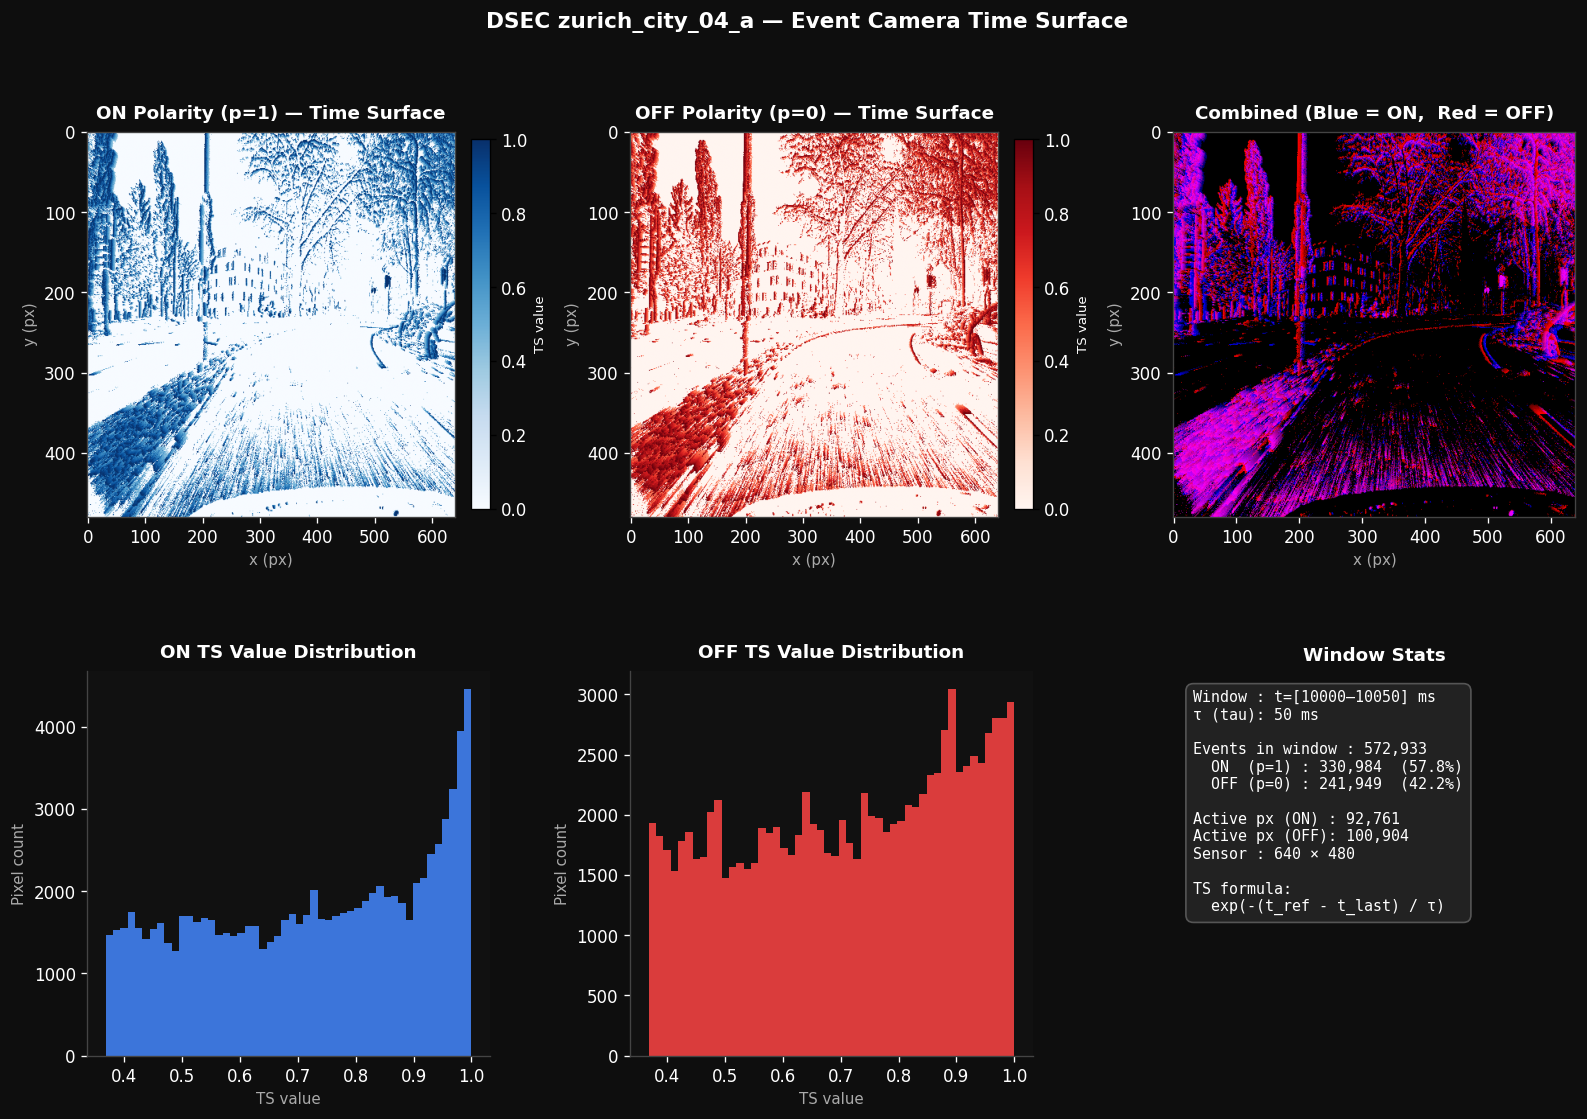

In [12]:
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('#0e0e0e')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

title_kw = dict(color='white', fontsize=11, fontweight='bold', pad=8)
label_kw = dict(color='#aaaaaa', fontsize=9)

def _dark_ax(ax):
    ax.set_facecolor('#111')
    ax.tick_params(colors='white')
    for sp in ax.spines.values(): sp.set_edgecolor('#444')

# ON polarity
ax1 = fig.add_subplot(gs[0, 0])
_dark_ax(ax1)
im1 = ax1.imshow(TS_pos, cmap='Blues', vmin=0, vmax=1, aspect='auto')
ax1.set_title('ON Polarity (p=1) — Time Surface', **title_kw)
ax1.set_xlabel('x (px)', **label_kw); ax1.set_ylabel('y (px)', **label_kw)
cb1 = fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
cb1.set_label('TS value', color='white', fontsize=8)
[t.set_color('white') for t in cb1.ax.get_yticklabels()]

#  OFF polarity
ax2 = fig.add_subplot(gs[0, 1])
_dark_ax(ax2)
im2 = ax2.imshow(TS_neg, cmap='Reds', vmin=0, vmax=1, aspect='auto')
ax2.set_title('OFF Polarity (p=0) — Time Surface', **title_kw)
ax2.set_xlabel('x (px)', **label_kw); ax2.set_ylabel('y (px)', **label_kw)
cb2 = fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
cb2.set_label('TS value', color='white', fontsize=8)
[t.set_color('white') for t in cb2.ax.get_yticklabels()]

#  Combined
ax3 = fig.add_subplot(gs[0, 2])
_dark_ax(ax3)
ax3.imshow(TS_combined, aspect='auto')
ax3.set_title('Combined (Blue = ON,  Red = OFF)', **title_kw)
ax3.set_xlabel('x (px)', **label_kw); ax3.set_ylabel('y (px)', **label_kw)

#  ON histogram
ax4 = fig.add_subplot(gs[1, 0])
_dark_ax(ax4)
ax4.hist(TS_pos[mask_pos], bins=50, color='#4488ff', edgecolor='none', alpha=0.85)
ax4.set_title('ON TS Value Distribution', **title_kw)
ax4.set_xlabel('TS value', **label_kw); ax4.set_ylabel('Pixel count', **label_kw)
ax4.spines['top'].set_visible(False); ax4.spines['right'].set_visible(False)

#  OFF histogram
ax5 = fig.add_subplot(gs[1, 1])
_dark_ax(ax5)
ax5.hist(TS_neg[mask_neg], bins=50, color='#ff4444', edgecolor='none', alpha=0.85)
ax5.set_title('OFF TS Value Distribution', **title_kw)
ax5.set_xlabel('TS value', **label_kw); ax5.set_ylabel('Pixel count', **label_kw)
ax5.spines['top'].set_visible(False); ax5.spines['right'].set_visible(False)

#  Stats panel
ax6 = fig.add_subplot(gs[1, 2])
ax6.set_facecolor('#1a1a1a'); ax6.axis('off')
stats_text = (
    f"Window : t=[{T_START_MS}–{T_END_MS}] ms\n"
    f"τ (tau): {TAU_US/1000:.0f} ms\n\n"
    f"Events in window : {n_win:,}\n"
    f"  ON  (p=1) : {int((ps==1).sum()):,}  ({(ps==1).mean()*100:.1f}%)\n"
    f"  OFF (p=0) : {int((ps==0).sum()):,}  ({(ps==0).mean()*100:.1f}%)\n\n"
    f"Active px (ON) : {mask_pos.sum():,}\n"
    f"Active px (OFF): {mask_neg.sum():,}\n"
    f"Sensor : 640 × 480\n\n"
    f"TS formula:\n"
    f"  exp(-(t_ref - t_last) / τ)"
)
ax6.text(0.05, 0.95, stats_text, transform=ax6.transAxes, fontsize=9,
         va='top', color='white', fontfamily='monospace',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#222', edgecolor='#555'))
ax6.set_title('Window Stats', color='white', fontsize=11, fontweight='bold')

fig.suptitle(
    'DSEC zurich_city_04_a — Event Camera Time Surface\n',
    color='white', fontsize=13, fontweight='bold', y=0.98
)

SAVE_PATH = os.path.join(FIGURES_DIR, "time_surface_example.png")
plt.savefig(SAVE_PATH, dpi=150, bbox_inches='tight', facecolor='#0e0e0e')
print(f"Figure saved → {SAVE_PATH}")
plt.show()

## 5. τ sensitivity - multi-tau comparison

The time constant $\tau$ controls the temporal memory of the surface.  
- Small $\tau$ → only the most recent events survive (sharp, sparse).  
- Large $\tau$ → older events still contribute (dense, blurred in time).

We visualise the ON channel across four $\tau$ values.

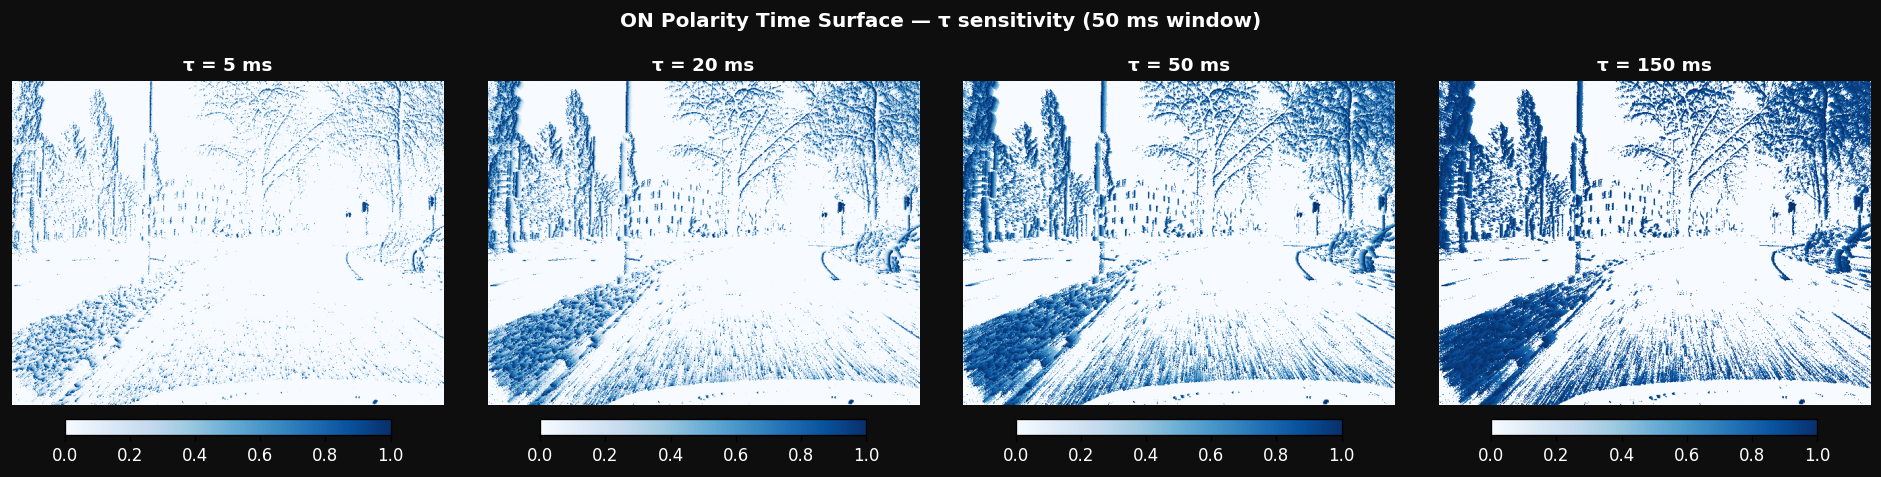

In [9]:
tau_values_ms = [5, 20, 50, 150]   # milliseconds

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.patch.set_facecolor('#0e0e0e')

for ax, tau_ms in zip(axes, tau_values_ms):
    tau_us = tau_ms * 1000
    ts_tau = np.zeros((HEIGHT, WIDTH), dtype=np.float32)
    ts_tau[mask_pos] = np.exp(-(t_ref - t_last_pos[mask_pos]) / tau_us)

    ax.set_facecolor('#111')
    im = ax.imshow(ts_tau, cmap='Blues', vmin=0, vmax=1, aspect='auto')
    ax.set_title(f'τ = {tau_ms} ms', color='white', fontsize=11, fontweight='bold')
    ax.axis('off')
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, orientation='horizontal')
    [t.set_color('white') for t in cb.ax.get_xticklabels()]

fig.suptitle('ON Polarity Time Surface — τ sensitivity (50 ms window)',
             color='white', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Summary stats for Milestone Report

These numbers go directly into Section 3 of the Milestone Report.

In [10]:
print("━" * 55)
print(" MILESTONE REPORT — Event Camera EDA Summary")
print("━" * 55)
print(f"  Dataset              : DSEC zurich_city_04_a (left)")
print(f"  Total events         : {N:,}")
print(f"  Time range (µs)      : [{t_min_us:,} – {t_max_us:,}]")
print(f"  Duration             : {duration_s:.3f} s ({duration_s/60:.2f} min)")
print(f"  Polarity  ON  (p=1)  : {pct_pos:.1f}%")
print(f"  Polarity  OFF (p=0)  : {100-pct_pos:.1f}%")
print(f"  Sensor resolution    : 640 × 480 px")
print(f"  Mean event rate      : {N/duration_s/1e6:.2f} Mev/s")
print(f"  Time Surface τ used  : 50 ms")
print(f"  Window for figure    : t=[10000–10050] ms  ({n_win:,} events)")
print("━" * 55)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 MILESTONE REPORT — Event Camera EDA Summary
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Dataset              : DSEC zurich_city_04_a (left)
  Total events         : 358,941,868
  Time range (µs)      : [0 – 35,001,999]
  Duration             : 35.002 s (0.58 min)
  Polarity  ON  (p=1)  : 59.6%
  Polarity  OFF (p=0)  : 40.4%
  Sensor resolution    : 640 × 480 px
  Mean event rate      : 10.25 Mev/s
  Time Surface τ used  : 50 ms
  Window for figure    : t=[10000–10050] ms  (572,933 events)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
